<a href="https://colab.research.google.com/github/Sivanunna/Logicmojo-AI-ML-Sept25--siva-/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Filtering out the warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/Home/assignment2/day.csv')
df


MessageError: Error: credential propagation was unsuccessful

In [ ]:
columns_to_drop = ['instant' , 'casual', 'registered']
df.drop(columns=columns_to_drop, inplace=True)
df

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,985
1,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,801
2,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,1349
3,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,1562
4,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,27-12-2019,1,1,12,0,5,1,2,10.420847,11.33210,65.2917,23.458911,2114
726,28-12-2019,1,1,12,0,6,0,2,10.386653,12.75230,59.0000,10.416557,3095
727,29-12-2019,1,1,12,0,0,0,2,10.386653,12.12000,75.2917,8.333661,1341
728,30-12-2019,1,1,12,0,1,1,1,10.489153,11.58500,48.3333,23.500518,1796


In [ ]:
df.isnull().sum()

,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0
atemp,0


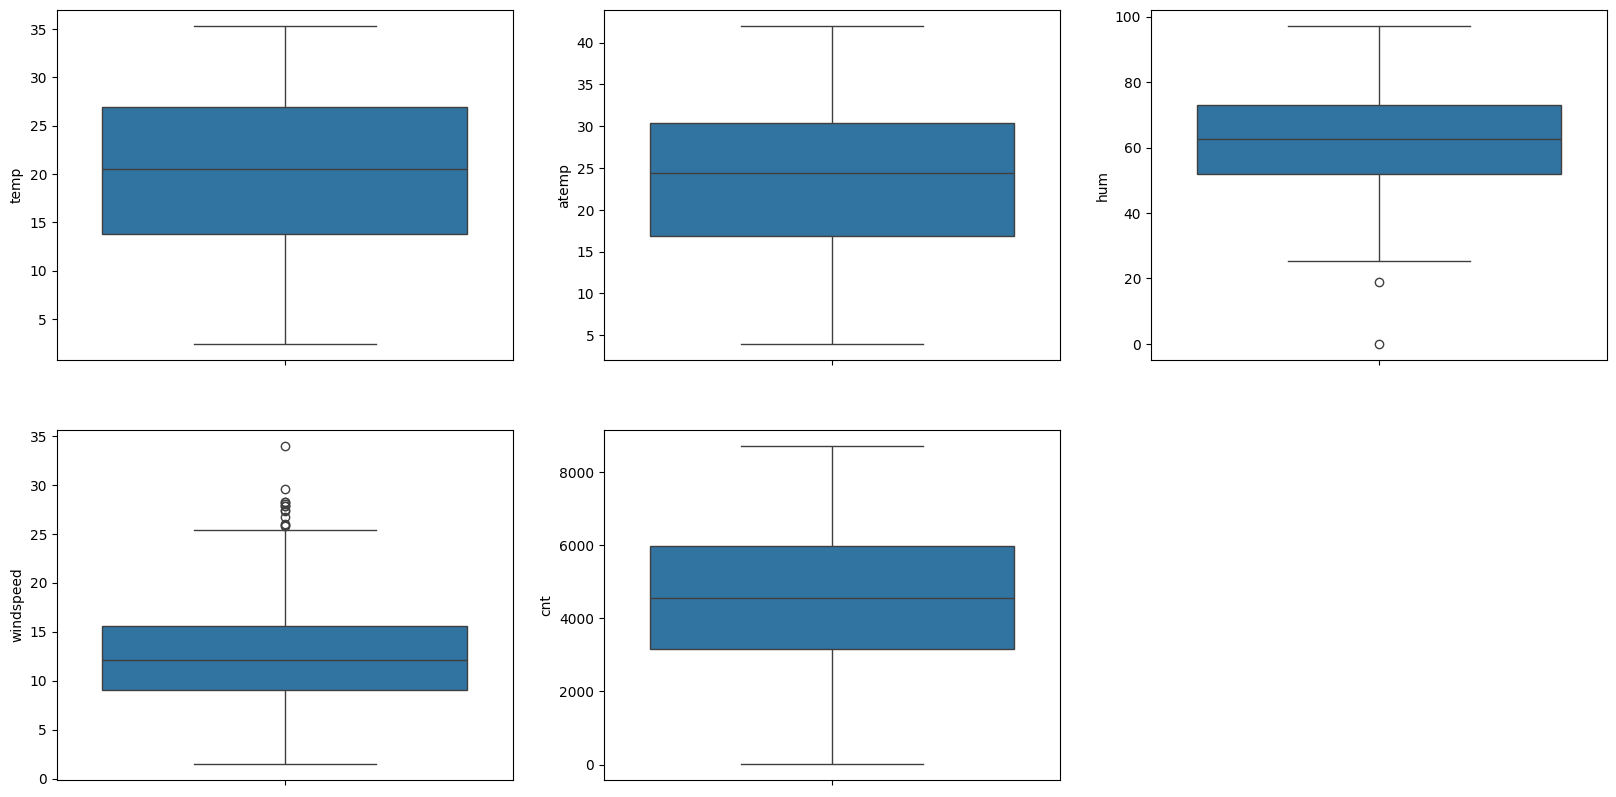

In [ ]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sns.boxplot(df['temp'])
plt.subplot(2,3,2)
sns.boxplot(df['atemp'])
plt.subplot(2,3,3)
sns.boxplot(df['hum'])
plt.subplot(2,3,4)
sns.boxplot(df['windspeed'])
plt.subplot(2,3,5)
sns.boxplot(df['cnt'])
plt.show()

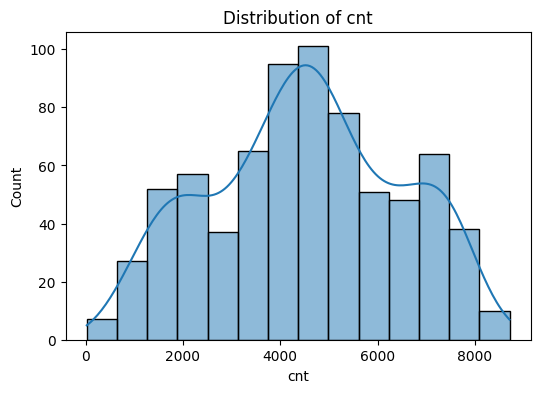

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['cnt'], kde=True)
plt.title('Distribution of cnt')
plt.show()

In [ ]:
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}
bikes_registered = (df.groupby('season')['cnt'].sum().reset_index().assign(season_name=lambda x: x['season'].map(season_map)).sort_values('cnt', ascending=False))
bikes_registered



,season,cnt,season_name
2,3,1061129,Fall
1,2,918589,Summer
3,4,841613,Winter
0,1,469514,Spring


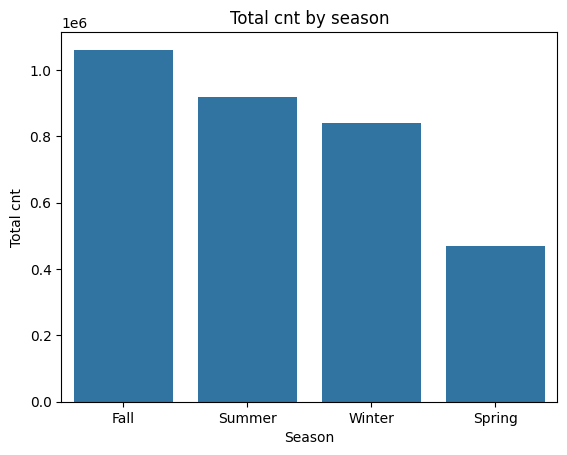

In [ ]:
sns.barplot(
    x='season_name',
    y='cnt',
    data=bikes_registered,
)
plt.title('Total cnt by season')
plt.xlabel('Season')
plt.ylabel('Total cnt')
plt.show()

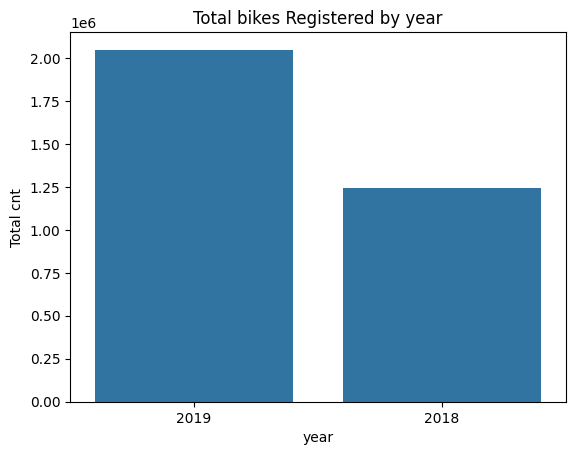

In [ ]:
year = df.groupby('yr')['cnt'].sum().reset_index().assign(yr_name=lambda x: x.index.map({0: '2018', 1: '2019'})).sort_values('cnt', ascending=False)
sns.barplot(
    x='yr_name',
    y='cnt',
    data=year,
)
plt.title('Total bikes Registered by year')
plt.xlabel('year')
plt.ylabel('Total cnt')
plt.show()

In [ ]:
df.groupby(['yr','workingday'])['cnt'].sum()


yr  workingday
0   0              378591
    1              864512
1   0              658266
    1             1389476
Name: cnt, dtype: int64

In [ ]:
df.groupby('yr')[['temp','hum','windspeed']].mean()



,temp,hum,windspeed
yr,,,
0,19.953263,64.366477,12.823977
1,20.685256,61.163873,12.703263


In [ ]:
df.groupby(['yr','holiday'])['cnt'].sum()

yr  holiday
0   0          1213081
    1            30022
1   0          1999329
    1            48413
Name: cnt, dtype: int64

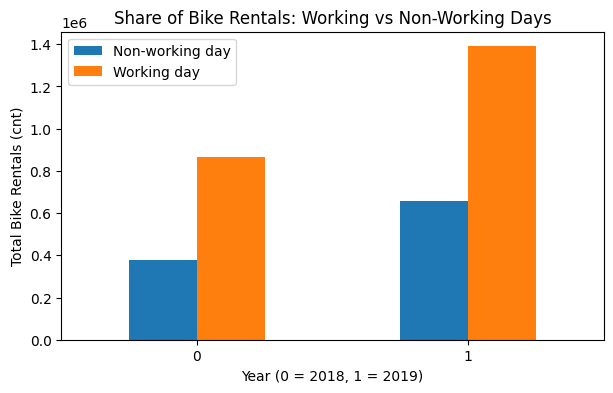

In [ ]:
grouped = df.groupby(['yr','workingday'])['cnt'].sum().unstack()

grouped.plot(kind='bar', figsize=(7,4))
plt.xlabel('Year (0 = 2018, 1 = 2019)')
plt.ylabel('Total Bike Rentals (cnt)')
plt.xticks(rotation=0)
plt.title('Share of Bike Rentals: Working vs Non-Working Days')
plt.legend(['Non-working day', 'Working day'])
plt.show()

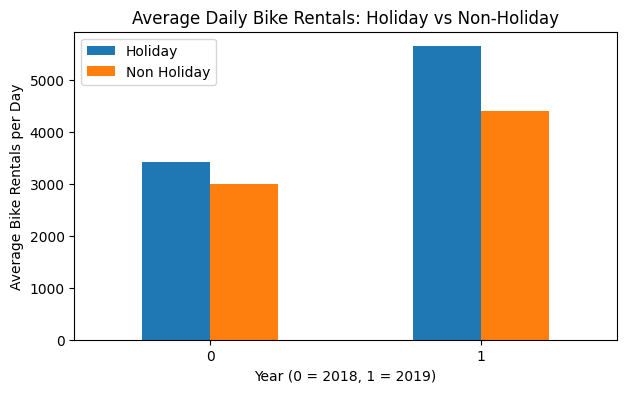

In [ ]:
grouped_mean = df.groupby(['yr', 'holiday'])['cnt'].mean().unstack()

grouped_mean.plot(kind='bar', figsize=(7,4))
plt.xlabel('Year (0 = 2018, 1 = 2019)')
plt.ylabel('Average Bike Rentals per Day')
plt.title('Average Daily Bike Rentals: Holiday vs Non-Holiday')
plt.legend(['Holiday', 'Non Holiday'])
plt.xticks(rotation=0)
plt.show()


In [ ]:
# weather_year = df.groupby('yr')[['temp','hum','windspeed']].mean().reset_index()
# weather_year.plot(kind='bar', figsize=(7,4))
# plt.xlabel('Year (0 = 2018, 1 = 2019)')
# plt.ylabel('Average Value')
# plt.title('Average Weather Conditions by Year')
# plt.xticks(rotation=0)
# plt.legend(title='Weather Variables')
# plt.show()

In [ ]:
# plt.figure(figsize = (20,10))
# sns.heatmap(df.corr(), annot = True)

In [ ]:
df.drop('dteday',inplace=True,axis=1)

In [ ]:
season_dummies  = pd.get_dummies(df['season'], prefix='season', drop_first=True)
df = pd.concat([df, season_dummies], axis=1)

In [ ]:
df.drop('season',inplace=True,axis=1)


In [ ]:
month_dummies = pd.get_dummies(df['mnth'], prefix='month', drop_first=True)
df = pd.concat([df, month_dummies], axis=1)

In [ ]:
df.drop('mnth',inplace=True,axis=1)


In [ ]:
yr_dummies = pd.get_dummies(df['yr'],prefix='year',drop_first=True)
df=pd.concat([df,yr_dummies],axis=1)

In [ ]:
df.drop('yr',inplace=True,axis=1)


In [ ]:
weekday_dummies = pd.get_dummies(df['weekday'],prefix='weekday',drop_first=True)
df=pd.concat([df,weekday_dummies],axis=1)

In [ ]:
df.drop('weekday',inplace=True,axis=1)


In [ ]:
workingday_dummies = pd.get_dummies(df['workingday'],prefix='workingday',drop_first=True)
df=pd.concat([df,workingday_dummies],axis=1)

In [ ]:
df.drop('workingday',inplace=True,axis=1)


In [ ]:
holiday_dummies= pd.get_dummies(df['holiday'],prefix='holiday',drop_first=True)
df=pd.concat([df,holiday_dummies],axis=1)

In [ ]:
df.drop('holiday',inplace=True,axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 29 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   weathersit    730 non-null    int64  
 1   temp          730 non-null    float64
 2   atemp         730 non-null    float64
 3   hum           730 non-null    float64
 4   windspeed     730 non-null    float64
 5   cnt           730 non-null    int64  
 6   season_2      730 non-null    bool   
 7   season_3      730 non-null    bool   
 8   season_4      730 non-null    bool   
 9   month_2       730 non-null    bool   
 10  month_3       730 non-null    bool   
 11  month_4       730 non-null    bool   
 12  month_5       730 non-null    bool   
 13  month_6       730 non-null    bool   
 14  month_7       730 non-null    bool   
 15  month_8       730 non-null    bool   
 16  month_9       730 non-null    bool   
 17  month_10      730 non-null    bool   
 18  month_11      730 non-null    

In [ ]:
weathersit_dummies = pd.get_dummies(df['weathersit'],prefix='weathersit',drop_first=True)
df=pd.concat([df,weathersit_dummies],axis=1)

In [ ]:
df.drop('weathersit',inplace=True,axis=1)
# df.info()

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
df_train, df_test = train_test_split(df, train_size= 0.70, test_size=0.30, random_state=100)

In [ ]:
df_train.shape

(510, 30)

In [ ]:
df_test.shape

(219, 30)

In [ ]:
bool_cols = df_train.select_dtypes(include='bool').columns
df_train[bool_cols] = df_train[bool_cols].astype(int)

In [ ]:
df_train

,temp,atemp,hum,windspeed,cnt,season_2,season_3,season_4,month_2,month_3,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,holiday_1,weathersit_2,weathersit_3
653,19.201653,23.04230,55.8333,12.208807,7534,0,0,1,0,0,...,0,0,1,0,0,0,1,0,0,0
576,29.246653,33.14480,70.4167,11.083475,7216,0,1,0,0,0,...,0,0,1,0,0,0,1,0,0,0
426,16.980847,20.67460,62.1250,10.792293,4066,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
728,10.489153,11.58500,48.3333,23.500518,1796,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
482,15.443347,18.87520,48.9583,8.708325,4220,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,29.554153,32.98605,58.7917,13.916771,6664,1,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0
578,30.852500,35.35440,65.9583,8.666718,7261,0,1,0,0,0,...,0,0,0,0,1,0,1,0,0,0
53,9.091299,12.28585,42.3043,6.305571,1917,0,0,0,1,0,...,0,0,0,0,1,0,1,0,0,0
350,10.591653,12.46855,56.0833,16.292189,2739,0,0,1,0,0,...,1,0,0,0,0,0,1,0,1,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_var = ['temp','atemp',  'hum','windspeed' ]

df_train[num_var] = scaler.fit_transform(df_train[num_var])

In [ ]:
df_train.describe()

,temp,atemp,hum,windspeed,cnt,season_2,season_3,season_4,month_2,month_3,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,holiday_1,weathersit_2,weathersit_3
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.00000,510.000000,510.000000,...,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,0.537262,0.512989,0.650369,0.320768,4486.382353,0.245098,0.262745,0.24902,0.066667,0.098039,...,0.154902,0.152941,0.135294,0.143137,0.147059,0.129412,0.711765,0.025490,0.343137,0.029412
std,0.225844,0.212385,0.145882,0.169797,1952.158739,0.430568,0.440557,0.43287,0.249689,0.297660,...,0.362166,0.360284,0.342373,0.350557,0.354512,0.335985,0.453386,0.157763,0.475223,0.169124
min,0.000000,0.000000,0.000000,0.000000,22.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.339853,0.332086,0.538643,0.199179,3120.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.540519,0.526811,0.653714,0.296763,4530.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.735215,0.688457,0.754830,0.414447,5973.500000,0.000000,1.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,8714.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

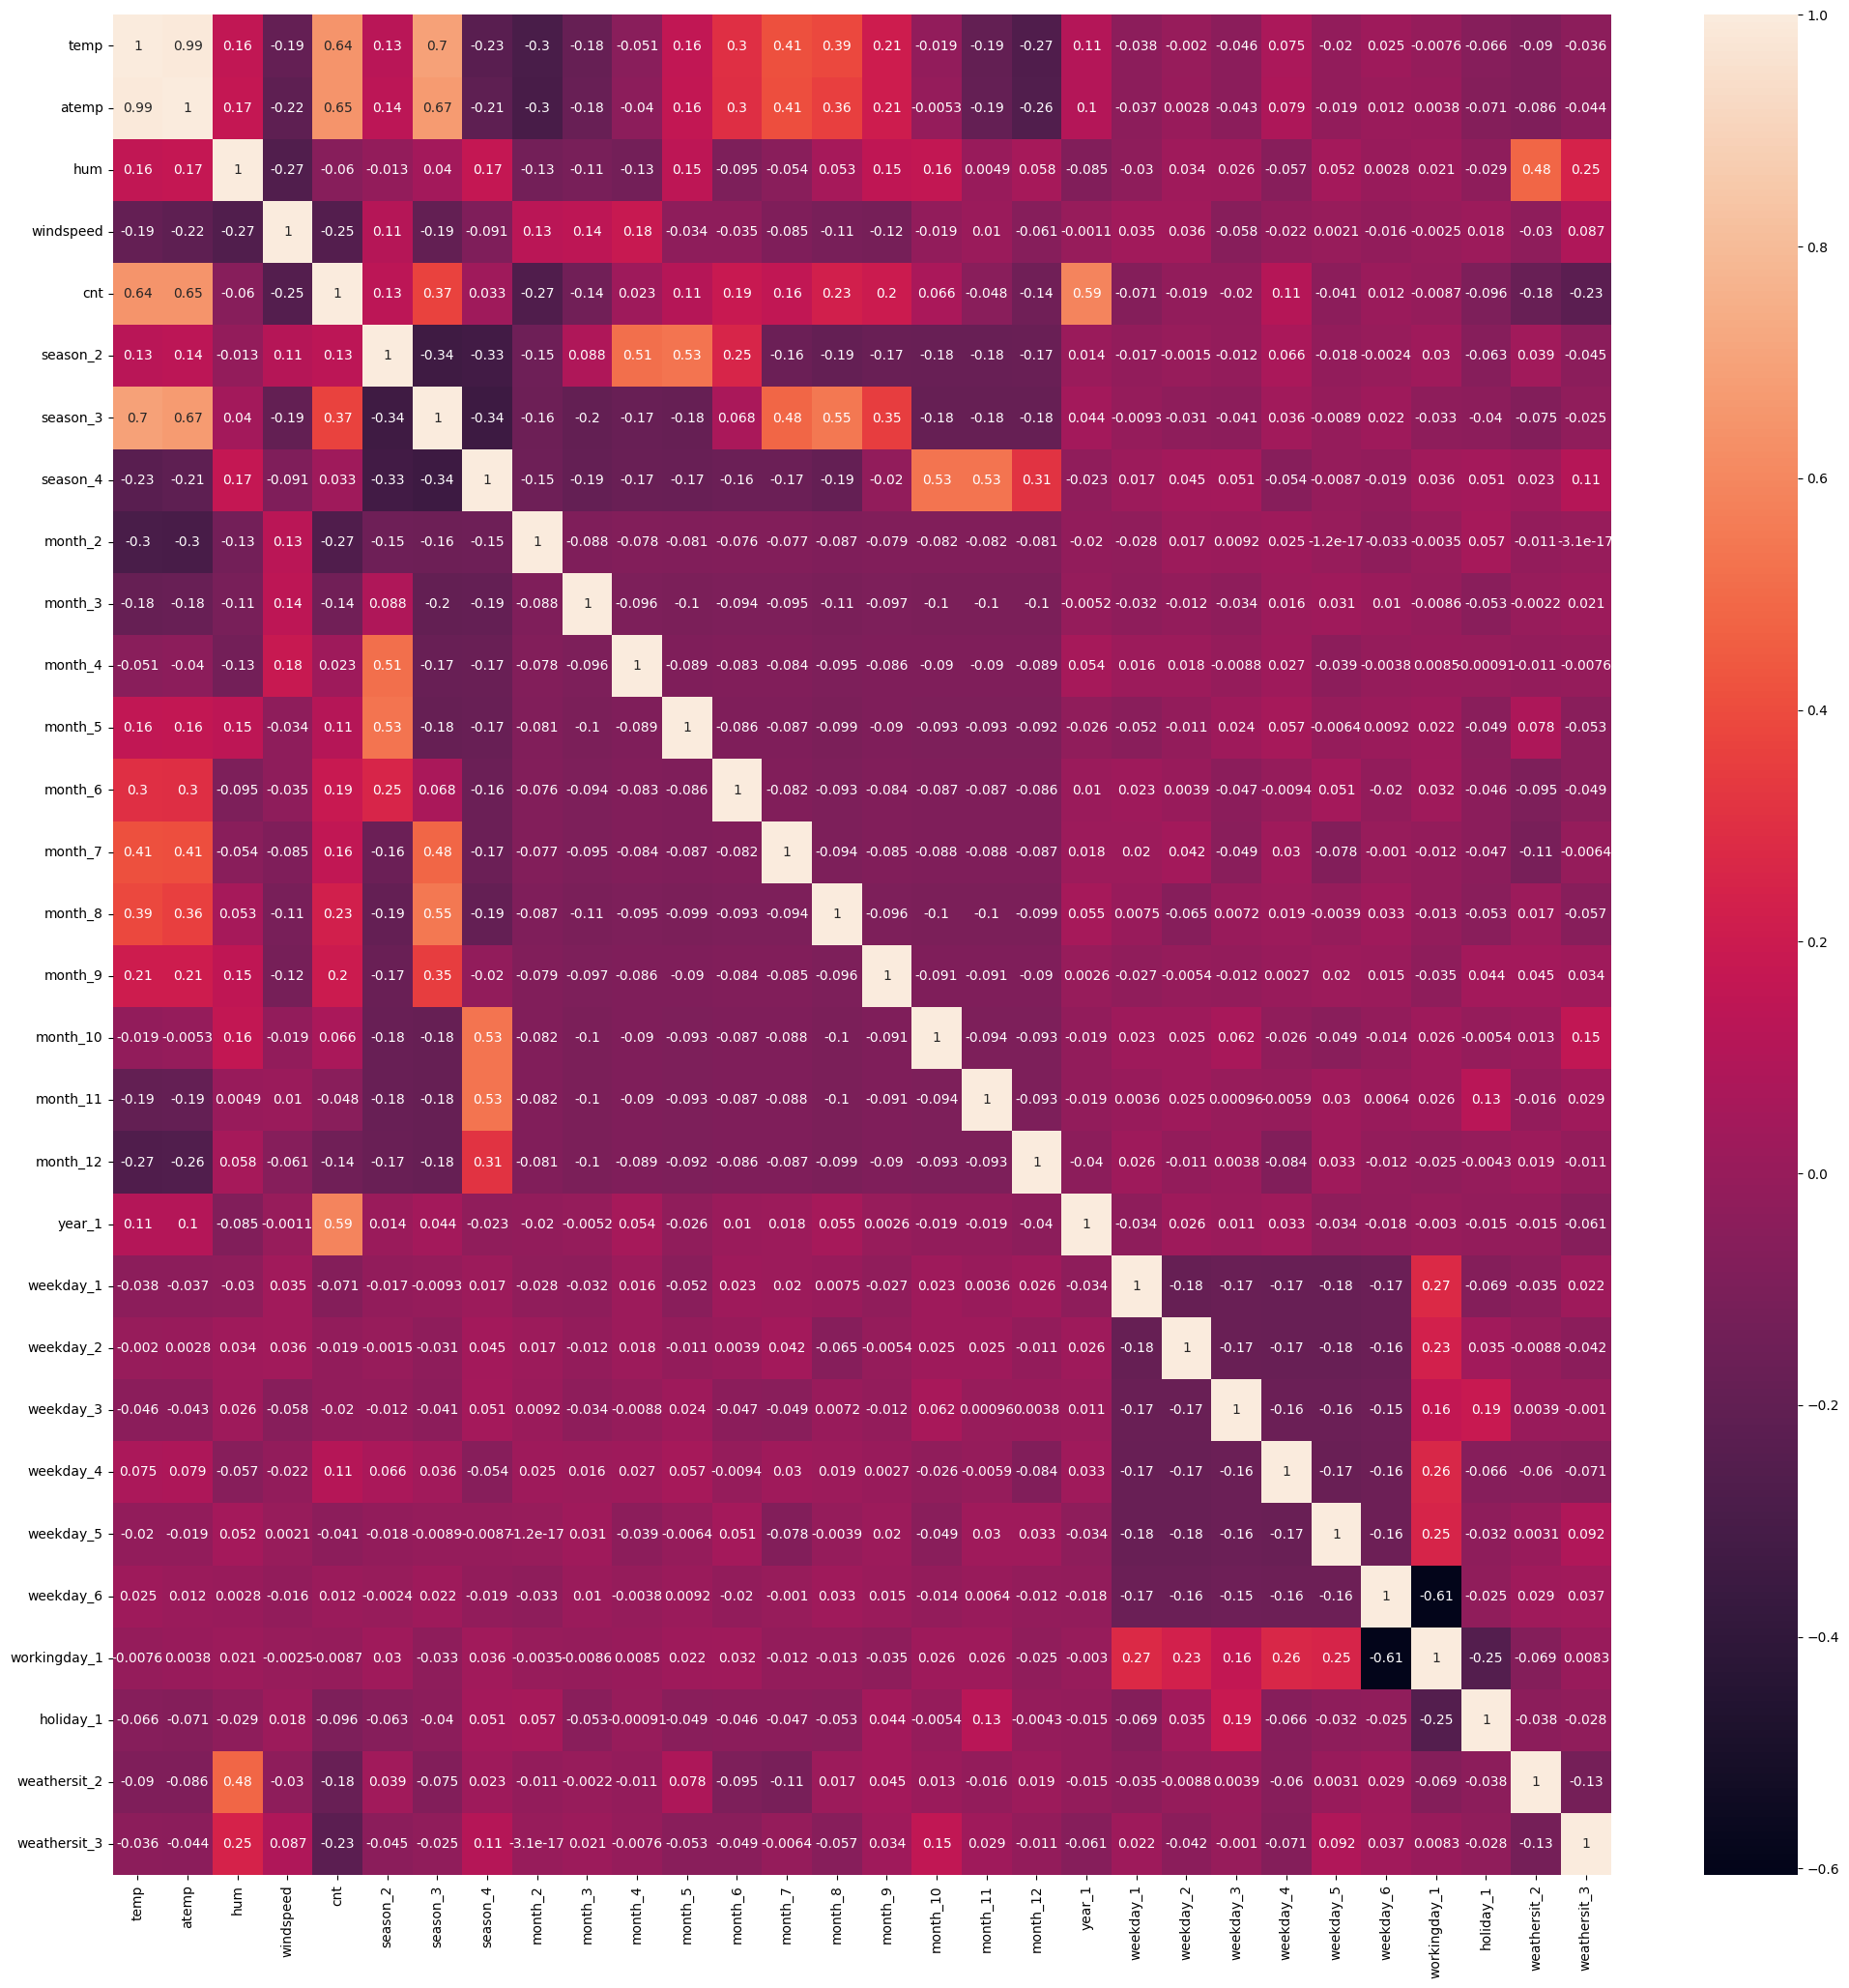

In [ ]:
plt.figure(figsize = (25,25))
sns.heatmap(df_train.corr(), annot = True)

In [ ]:
df_train.drop('atemp',inplace=True,axis=1)

In [ ]:
# drop one season dummy
df_train.drop('season_2', axis=1, inplace=True)


In [ ]:
df_train.drop('temp',inplace=True,axis=1)

In [ ]:
import statsmodels.api as sm

In [ ]:
y_train =  df_train.pop('cnt')
x_train = df_train

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_train_const = sm.add_constant(x_train)
vif = pd.DataFrame()
vif['Feature'] = X_train_const.columns
vif['VIF'] = [
    variance_inflation_factor(X_train_const.values, i)
    for i in range(X_train_const.shape[1])
]

vif.sort_values(by='VIF', ascending=False)


,Feature,VIF
23,workingday_1,66.212650
0,const,57.481590
17,weekday_1,42.877917
18,weekday_2,41.977897
21,weekday_5,41.003182
20,weekday_4,40.279025
19,weekday_3,37.373715
3,season_3,7.814950
4,season_4,7.568305
24,holiday_1,6.796937


In [ ]:
x_train.drop(columns=['workingday_1'], inplace=True)


In [ ]:
X_train_const = sm.add_constant(x_train)
lr = sm.OLS(y_train, X_train_const).fit()
lr.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     87.41
Date:                Tue, 03 Feb 2026   Prob (F-statistic):          9.06e-162
Time:                        10:02:59   Log-Likelihood:                -4151.9
No. Observations:                 510   AIC:                             8356.
Df Residuals:                     484   BIC:                             8466.
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2336.9436    285.862      8.175      0.000    1775.259    2898.628
hum           -429.7793    356.788     -1.205      0.229   -1130.824     271.265
windspeed    -1553.8170    248.209     -6.260      0.000   -2041.518   -1066.116
season_3       184.2202    239.762      0.768      0.443    -286.883     655.324
season_4      1212.3987    239.898      5.054      0.000     741.028    1683.769
month_2        530.2291    195.446      2.713      0.007     146.201     914.257
month_3       1603.7344    176.988      9.061      0.000    1255.974    1951.495
month_4       2402.0931    187.692     12.798      0.000    2033.301    2770.886
month_5       3111.6311    185.966     16.732      0.000    2746.230    3477.032
month_6       3262.3302    209.025     15.607      0.000    2851.621    3673.039
month_7       2907.2351    305.141      9.528      0.000    2307.670    3506.800
month_8       3148.6125    298.681     10.542      0.000    2561.740    3735.485
month_9       3247.8337    285.359     11.382      0.000    2687.137    3808.530
month_10      1854.7443    302.256      6.136      0.000    1260.848    2448.640
month_11       952.9539    302.177      3.154      0.002     359.213    1546.695
month_12       664.2703    247.724      2.681      0.008     177.523    1151.018
year_1        2124.9815     76.405     27.812      0.000    1974.855    2275.108
weekday_1     -376.0306    141.192     -2.663      0.008    -653.455     -98.606
weekday_2     -337.4433    141.913     -2.378      0.018    -616.285     -58.602
weekday_3     -206.3751    147.516     -1.399      0.162    -496.226      83.476
weekday_4       -7.5428    144.322     -0.052      0.958    -291.117     276.031
weekday_5      -77.6894    143.498     -0.541      0.588    -359.645     204.266
weekday_6      -35.3154    147.038     -0.240      0.810    -324.227     253.596
holiday_1     -587.9536    250.214     -2.350      0.019   -1079.593     -96.314
weathersit_2  -672.4849     98.675     -6.815      0.000    -866.370    -478.600
weathersit_3 -2450.9135    251.775     -9.735      0.000   -2945.621   -1956.206
==============================================================================
Omnibus:                       73.388   Durbin-Watson:                   1.903
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              259.135
Skew:                          -0.622   Prob(JB):                     5.36e-57
Kurtosis:                       6.263   Cond. No.                         26.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
vif = pd.DataFrame()
vif['Feature'] = X_train_const.columns
vif['VIF'] = [
    variance_inflation_factor(X_train_const.values, i)
    for i in range(X_train_const.shape[1])
]

vif.sort_values(by='VIF', ascending=False)

,Feature,VIF
0,const,57.348430
3,season_3,7.814872
4,season_4,7.553080
11,month_8,5.437264
13,month_10,5.054238
14,month_11,5.051603
10,month_7,4.614815
12,month_9,4.224825
15,month_12,3.324984
9,month_6,2.114419


In [ ]:
x_train.drop(columns=['season_3'], inplace=True)


In [ ]:
X_train_const = sm.add_constant(x_train)
lr = sm.OLS(y_train, X_train_const).fit()
lr.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     91.10
Date:                Tue, 03 Feb 2026   Prob (F-statistic):          1.26e-162
Time:                        10:02:59   Log-Likelihood:                -4152.2
No. Observations:                 510   AIC:                             8354.
Df Residuals:                     485   BIC:                             8460.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2349.3845    285.283      8.235      0.000    1788.842    2909.927
hum           -439.9529    356.391     -1.234      0.218   -1140.215     260.309
windspeed    -1566.5375    247.552     -6.328      0.000   -2052.944   -1080.131
season_4      1130.9974    215.146      5.257      0.000     708.263    1553.732
month_2        530.1717    195.364      2.714      0.007     146.308     914.035
month_3       1603.6327    176.913      9.065      0.000    1256.021    1951.244
month_4       2402.8154    187.611     12.807      0.000    2034.185    2771.446
month_5       3111.9191    185.887     16.741      0.000    2746.675    3477.163
month_6       3329.3396    189.882     17.534      0.000    2956.247    3702.432
month_7       3090.5159    190.209     16.248      0.000    2716.781    3464.250
month_8       3332.4347    178.733     18.645      0.000    2981.247    3683.622
month_9       3408.9473    193.465     17.620      0.000    3028.814    3789.081
month_10      1936.2524    282.909      6.844      0.000    1380.374    2492.131
month_11      1034.2977    282.905      3.656      0.000     478.427    1590.168
month_12       720.8730    236.417      3.049      0.002     256.345    1185.401
year_1        2125.0311     76.373     27.824      0.000    1974.968    2275.094
weekday_1     -381.7876    140.933     -2.709      0.007    -658.703    -104.872
weekday_2     -339.1193    141.836     -2.391      0.017    -617.808     -60.430
weekday_3     -207.2817    147.449     -1.406      0.160    -496.999      82.436
weekday_4       -7.7759    144.260     -0.054      0.957    -291.228     275.677
weekday_5      -76.6541    143.431     -0.534      0.593    -358.477     205.168
weekday_6      -38.5029    146.917     -0.262      0.793    -327.176     250.170
holiday_1     -589.3899    250.101     -2.357      0.019   -1080.806     -97.974
weathersit_2  -673.1734     98.629     -6.825      0.000    -866.967    -479.380
weathersit_3 -2443.0953    251.463     -9.716      0.000   -2937.188   -1949.003
==============================================================================
Omnibus:                       73.499   Durbin-Watson:                   1.910
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.288
Skew:                          -0.624   Prob(JB):                     8.19e-57
Kurtosis:                       6.255   Cond. No.                         20.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
vif = pd.DataFrame()
vif['Feature'] = X_train_const.columns
vif['VIF'] = [
    variance_inflation_factor(X_train_const.values, i)
    for i in range(X_train_const.shape[1])
]

vif.sort_values(by='VIF', ascending=False)

,Feature,VIF
0,const,57.164437
3,season_4,6.080025
12,month_10,4.431658
13,month_11,4.431530
14,month_12,3.030939
10,month_8,1.948692
5,month_3,1.943945
11,month_9,1.943558
1,hum,1.894873
7,month_5,1.873785


In [ ]:
X_train_const = sm.add_constant(x_train)
model = sm.OLS(y_train, X_train_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     91.10
Date:                Tue, 03 Feb 2026   Prob (F-statistic):          1.26e-162
Time:                        10:03:00   Log-Likelihood:                -4152.2
No. Observations:                 510   AIC:                             8354.
Df Residuals:                     485   BIC:                             8460.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2349.3845    285.283      8.235      0.000    1788.842    2909.927
hum           -439.9529    356.391     -1.234      0.218   -1140.215     260.309
windspeed    -1566.5375    247.552     -6.328      0.000   -2052.944   -1080.131
season_4      1130.9974    215.146      5.257      0.000     708.263    1553.732
month_2        530.1717    195.364      2.714      0.007     146.308     914.035
month_3       1603.6327    176.913      9.065      0.000    1256.021    1951.244
month_4       2402.8154    187.611     12.807      0.000    2034.185    2771.446
month_5       3111.9191    185.887     16.741      0.000    2746.675    3477.163
month_6       3329.3396    189.882     17.534      0.000    2956.247    3702.432
month_7       3090.5159    190.209     16.248      0.000    2716.781    3464.250
month_8       3332.4347    178.733     18.645      0.000    2981.247    3683.622
month_9       3408.9473    193.465     17.620      0.000    3028.814    3789.081
month_10      1936.2524    282.909      6.844      0.000    1380.374    2492.131
month_11      1034.2977    282.905      3.656      0.000     478.427    1590.168
month_12       720.8730    236.417      3.049      0.002     256.345    1185.401
year_1        2125.0311     76.373     27.824      0.000    1974.968    2275.094
weekday_1     -381.7876    140.933     -2.709      0.007    -658.703    -104.872
weekday_2     -339.1193    141.836     -2.391      0.017    -617.808     -60.430
weekday_3     -207.2817    147.449     -1.406      0.160    -496.999      82.436
weekday_4       -7.7759    144.260     -0.054      0.957    -291.228     275.677
weekday_5      -76.6541    143.431     -0.534      0.593    -358.477     205.168
weekday_6      -38.5029    146.917     -0.262      0.793    -327.176     250.170
holiday_1     -589.3899    250.101     -2.357      0.019   -1080.806     -97.974
weathersit_2  -673.1734     98.629     -6.825      0.000    -866.967    -479.380
weathersit_3 -2443.0953    251.463     -9.716      0.000   -2937.188   -1949.003
==============================================================================
Omnibus:                       73.499   Durbin-Watson:                   1.910
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.288
Skew:                          -0.624   Prob(JB):                     8.19e-57
Kurtosis:                       6.255   Cond. No.                         20.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
x_train.drop(columns=['weekday_4'], inplace=True)

In [ ]:
X_train_const = sm.add_constant(x_train)
model = sm.OLS(y_train, X_train_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     95.26
Date:                Tue, 03 Feb 2026   Prob (F-statistic):          1.27e-163
Time:                        10:03:00   Log-Likelihood:                -4152.2
No. Observations:                 510   AIC:                             8352.
Df Residuals:                     486   BIC:                             8454.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2345.6714    276.557      8.482      0.000    1802.277    2889.066
hum           -440.5800    355.836     -1.238      0.216   -1139.747     258.587
windspeed    -1566.1990    247.218     -6.335      0.000   -2051.948   -1080.451
season_4      1131.0061    214.926      5.262      0.000     708.708    1553.304
month_2        529.8756    195.086      2.716      0.007     146.560     913.192
month_3       1603.4812    176.710      9.074      0.000    1256.272    1950.690
month_4       2402.4530    187.298     12.827      0.000    2034.440    2770.466
month_5       3111.4699    185.510     16.773      0.000    2746.969    3475.971
month_6       3329.3207    189.687     17.552      0.000    2956.614    3702.028
month_7       3090.5235    190.013     16.265      0.000    2717.175    3463.872
month_8       3332.3068    178.534     18.665      0.000    2981.512    3683.101
month_9       3408.8546    193.259     17.639      0.000    3029.128    3788.581
month_10      1936.1270    282.609      6.851      0.000    1380.841    2491.413
month_11      1033.8887    282.513      3.660      0.000     478.791    1588.986
month_12       721.3196    236.029      3.056      0.002     257.556    1185.083
year_1        2125.0026     76.293     27.853      0.000    1975.098    2274.907
weekday_1     -377.8485    120.382     -3.139      0.002    -614.381    -141.316
weekday_2     -335.1483    121.078     -2.768      0.006    -573.049     -97.248
weekday_3     -203.3438    127.946     -1.589      0.113    -454.739      48.052
weekday_5      -72.7235    123.384     -0.589      0.556    -315.155     169.708
weekday_6      -34.5677    127.363     -0.271      0.786    -284.817     215.682
holiday_1     -588.9617    249.718     -2.359      0.019   -1079.623     -98.301
weathersit_2  -672.6607     98.069     -6.859      0.000    -865.352    -479.969
weathersit_3 -2442.5104    250.971     -9.732      0.000   -2935.633   -1949.388
==============================================================================
Omnibus:                       73.400   Durbin-Watson:                   1.910
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.158
Skew:                          -0.623   Prob(JB):                     8.74e-57
Kurtosis:                       6.255   Cond. No.                         20.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
x_train.drop(columns=['weekday_6'], inplace=True)

In [ ]:
X_train_const = sm.add_constant(x_train)
model = sm.OLS(y_train, X_train_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     99.78
Date:                Tue, 03 Feb 2026   Prob (F-statistic):          1.31e-164
Time:                        10:03:00   Log-Likelihood:                -4152.2
No. Observations:                 510   AIC:                             8350.
Df Residuals:                     487   BIC:                             8448.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2333.2054    272.457      8.564      0.000    1797.870    2868.541
hum           -439.8460    355.487     -1.237      0.217   -1138.324     258.632
windspeed    -1565.2122    246.956     -6.338      0.000   -2050.443   -1079.981
season_4      1132.4197    214.658      5.275      0.000     710.650    1554.190
month_2        532.1036    194.728      2.733      0.007     149.493     914.714
month_3       1604.4234    176.507      9.090      0.000    1257.614    1951.233
month_4       2403.4184    187.086     12.847      0.000    2035.823    2771.013
month_5       3112.4034    185.302     16.796      0.000    2748.314    3476.493
month_6       3330.2453    189.475     17.576      0.000    2957.955    3702.536
month_7       3092.1203    189.741     16.296      0.000    2719.307    3464.933
month_8       3332.3927    178.364     18.683      0.000    2981.934    3682.851
month_9       3409.2133    193.071     17.658      0.000    3029.859    3788.568
month_10      1935.6589    282.335      6.856      0.000    1380.914    2490.404
month_11      1032.3733    282.189      3.658      0.000     477.915    1586.831
month_12       720.9093    235.800      3.057      0.002     257.599    1184.220
year_1        2125.5653     76.192     27.898      0.000    1975.860    2275.271
weekday_1     -366.8041    113.188     -3.241      0.001    -589.200    -144.408
weekday_2     -324.3624    114.262     -2.839      0.005    -548.869     -99.856
weekday_3     -192.2437    121.118     -1.587      0.113    -430.222      45.735
weekday_5      -61.4678    116.095     -0.529      0.597    -289.577     166.641
holiday_1     -589.8779    249.458     -2.365      0.018   -1080.025     -99.731
weathersit_2  -673.2823     97.949     -6.874      0.000    -865.737    -480.828
weathersit_3 -2447.1949    250.139     -9.783      0.000   -2938.680   -1955.710
==============================================================================
Omnibus:                       73.269   Durbin-Watson:                   1.908
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              256.142
Skew:                          -0.624   Prob(JB):                     2.40e-56
Kurtosis:                       6.240   Cond. No.                         20.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
x_train.drop(columns=['weekday_5'], inplace=True)

In [ ]:
X_train_const = sm.add_constant(x_train)
model = sm.OLS(y_train, X_train_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     104.7
Date:                Tue, 03 Feb 2026   Prob (F-statistic):          1.45e-165
Time:                        10:03:00   Log-Likelihood:                -4152.4
No. Observations:                 510   AIC:                             8349.
Df Residuals:                     488   BIC:                             8442.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2321.8579    271.412      8.555      0.000    1788.578    2855.138
hum           -450.7914    354.624     -1.271      0.204   -1147.569     245.986
windspeed    -1566.8308    246.755     -6.350      0.000   -2051.665   -1081.997
season_4      1135.0712    214.441      5.293      0.000     713.729    1556.413
month_2        533.6146    194.563      2.743      0.006     151.330     915.900
month_3       1605.4732    176.366      9.103      0.000    1258.943    1952.004
month_4       2407.1978    186.812     12.886      0.000    2040.143    2774.252
month_5       3115.9958    185.041     16.840      0.000    2752.421    3479.571
month_6       3328.1628    189.295     17.582      0.000    2956.229    3700.096
month_7       3099.6334    189.071     16.394      0.000    2728.141    3471.126
month_8       3335.3716    178.144     18.723      0.000    2985.348    3685.395
month_9       3410.8331    192.904     17.681      0.000    3031.808    3789.858
month_10      1938.0301    282.091      6.870      0.000    1383.767    2492.293
month_11      1029.3218    281.922      3.651      0.000     475.391    1583.252
month_12       718.5427    235.584      3.050      0.002     255.659    1181.426
year_1        2126.4023     76.119     27.935      0.000    1976.840    2275.964
weekday_1     -350.4721    108.823     -3.221      0.001    -564.292    -136.653
weekday_2     -308.3681    110.115     -2.800      0.005    -524.726     -92.011
weekday_3     -176.0805    117.121     -1.503      0.133    -406.205      54.044
holiday_1     -589.8988    249.274     -2.366      0.018   -1079.682    -100.116
weathersit_2  -671.6073     97.826     -6.865      0.000    -863.819    -479.396
weathersit_3 -2455.9325    249.410     -9.847      0.000   -2945.982   -1965.883
==============================================================================
Omnibus:                       73.088   Durbin-Watson:                   1.911
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.493
Skew:                          -0.618   Prob(JB):                     7.40e-57
Kurtosis:                       6.261   Cond. No.                         20.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
x_train.drop(columns=['hum'], inplace=True)

In [ ]:
X_train_const = sm.add_constant(x_train)
model = sm.OLS(y_train, X_train_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     109.7
Date:                Tue, 03 Feb 2026   Prob (F-statistic):          3.04e-166
Time:                        10:03:00   Log-Likelihood:                -4153.2
No. Observations:                 510   AIC:                             8348.
Df Residuals:                     489   BIC:                             8437.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2045.1319    162.197     12.609      0.000    1726.443    2363.820
windspeed    -1480.4350    237.360     -6.237      0.000   -1946.806   -1014.064
season_4      1132.4982    214.567      5.278      0.000     710.912    1554.085
month_2        539.1459    194.637      2.770      0.006     156.718     921.574
month_3       1603.7645    176.472      9.088      0.000    1257.028    1950.501
month_4       2407.4430    186.929     12.879      0.000    2040.160    2774.726
month_5       3072.8029    182.009     16.883      0.000    2715.187    3430.419
month_6       3318.9624    189.276     17.535      0.000    2947.069    3690.856
month_7       3084.7735    188.828     16.336      0.000    2713.760    3455.787
month_8       3307.9883    176.948     18.695      0.000    2960.316    3655.660
month_9       3372.3748    190.637     17.690      0.000    2997.806    3746.943
month_10      1901.0385    280.763      6.771      0.000    1349.388    2452.689
month_11      1013.0058    281.807      3.595      0.000     459.304    1566.707
month_12       694.0908    234.945      2.954      0.003     232.465    1155.717
year_1        2133.6836     75.951     28.093      0.000    1984.452    2282.915
weekday_1     -351.3622    108.889     -3.227      0.001    -565.311    -137.414
weekday_2     -320.6038    109.762     -2.921      0.004    -536.268    -104.940
weekday_3     -178.8655    117.175     -1.526      0.128    -409.093      51.362
holiday_1     -591.2207    249.429     -2.370      0.018   -1081.305    -101.136
weathersit_2  -740.3942     81.548     -9.079      0.000    -900.622    -580.167
weathersit_3 -2577.4873    230.496    -11.182      0.000   -3030.371   -2124.603
==============================================================================
Omnibus:                       73.996   Durbin-Watson:                   1.918
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.162
Skew:                          -0.632   Prob(JB):                     8.72e-57
Kurtosis:                       6.249   Cond. No.                         18.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
x_train.drop(columns=['weekday_3'], inplace=True)

In [ ]:
X_train_const = sm.add_constant(x_train)
model = sm.OLS(y_train, X_train_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     115.0
Date:                Tue, 03 Feb 2026   Prob (F-statistic):          8.84e-167
Time:                        10:03:00   Log-Likelihood:                -4154.4
No. Observations:                 510   AIC:                             8349.
Df Residuals:                     490   BIC:                             8434.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2000.8080    159.793     12.521      0.000    1686.844    2314.772
windspeed    -1463.8961    237.434     -6.165      0.000   -1930.411    -997.381
season_4      1119.1588    214.680      5.213      0.000     697.353    1540.965
month_2        544.8627    194.865      2.796      0.005     161.989     927.737
month_3       1615.0503    176.556      9.148      0.000    1268.150    1961.951
month_4       2412.6700    187.151     12.892      0.000    2044.952    2780.388
month_5       3075.1171    182.249     16.873      0.000    2717.030    3433.204
month_6       3333.1374    189.304     17.607      0.000    2961.189    3705.085
month_7       3098.2869    188.876     16.404      0.000    2727.180    3469.393
month_8       3314.6152    177.135     18.712      0.000    2966.578    3662.652
month_9       3388.1874    190.613     17.775      0.000    3013.667    3762.708
month_10      1906.3075    281.122      6.781      0.000    1353.954    2458.661
month_11      1036.0600    281.784      3.677      0.000     482.407    1589.713
month_12       708.8191    235.065      3.015      0.003     246.959    1170.679
year_1        2132.0797     76.047     28.036      0.000    1982.661    2281.498
weekday_1     -318.6572    106.905     -2.981      0.003    -528.707    -108.608
weekday_2     -284.8619    107.381     -2.653      0.008    -495.846     -73.877
holiday_1     -663.8495    245.181     -2.708      0.007   -1145.585    -182.114
weathersit_2  -739.0635     81.654     -9.051      0.000    -899.498    -578.629
weathersit_3 -2576.0484    230.806    -11.161      0.000   -3029.541   -2122.556
==============================================================================
Omnibus:                       74.479   Durbin-Watson:                   1.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              273.865
Skew:                          -0.619   Prob(JB):                     3.40e-60
Kurtosis:                       6.370   Cond. No.                         18.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
y_train_pred = model.predict(X_train_const)

<Axes: ylabel='Density'>

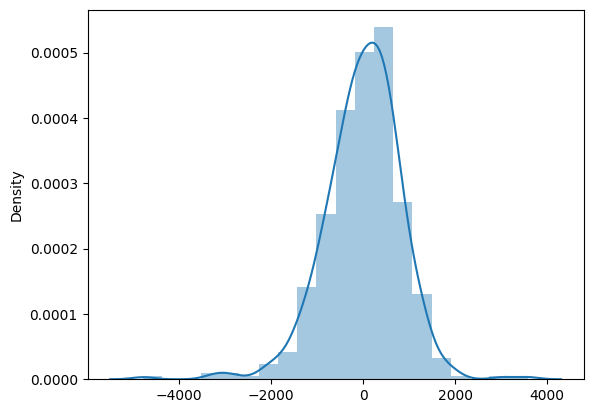

In [ ]:
sns.distplot((y_train - y_train_pred), bins = 20)

In [ ]:
bool_cols = df_test.select_dtypes(include='bool').columns
df_test[bool_cols] = df_test[bool_cols].astype(int)

In [ ]:
num_var = ['temp','atemp',  'hum','windspeed' ]

df_test[num_var] = scaler.fit_transform(df_test[num_var])

In [ ]:
df_test

,temp,atemp,hum,windspeed,cnt,season_2,season_3,season_4,month_2,month_3,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,holiday_1,weathersit_2,weathersit_3
184,0.837241,0.778767,0.534223,0.149393,6043,0,1,0,0,0,...,0,0,1,0,0,0,0,1,1,0
535,0.911423,0.855132,0.470417,0.231142,6211,1,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
299,0.496221,0.492359,0.777843,0.443398,2659,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0
221,0.890387,0.805661,0.236659,0.449707,4780,0,1,0,0,0,...,0,0,0,0,1,0,1,0,0,0
152,0.821739,0.749249,0.070765,0.682387,4968,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,0.224955,0.227731,0.603829,0.388364,2947,0,0,0,1,0,...,0,1,0,0,0,0,1,0,1,0
702,0.503971,0.508864,0.667633,0.383644,6606,0,0,1,0,0,...,0,0,1,0,0,0,1,0,0,0
127,0.573725,0.577423,0.525522,0.132095,4333,1,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
640,0.745342,0.687659,0.751160,0.111637,7572,0,0,1,0,0,...,0,0,0,1,0,0,1,0,1,0


<Axes: >

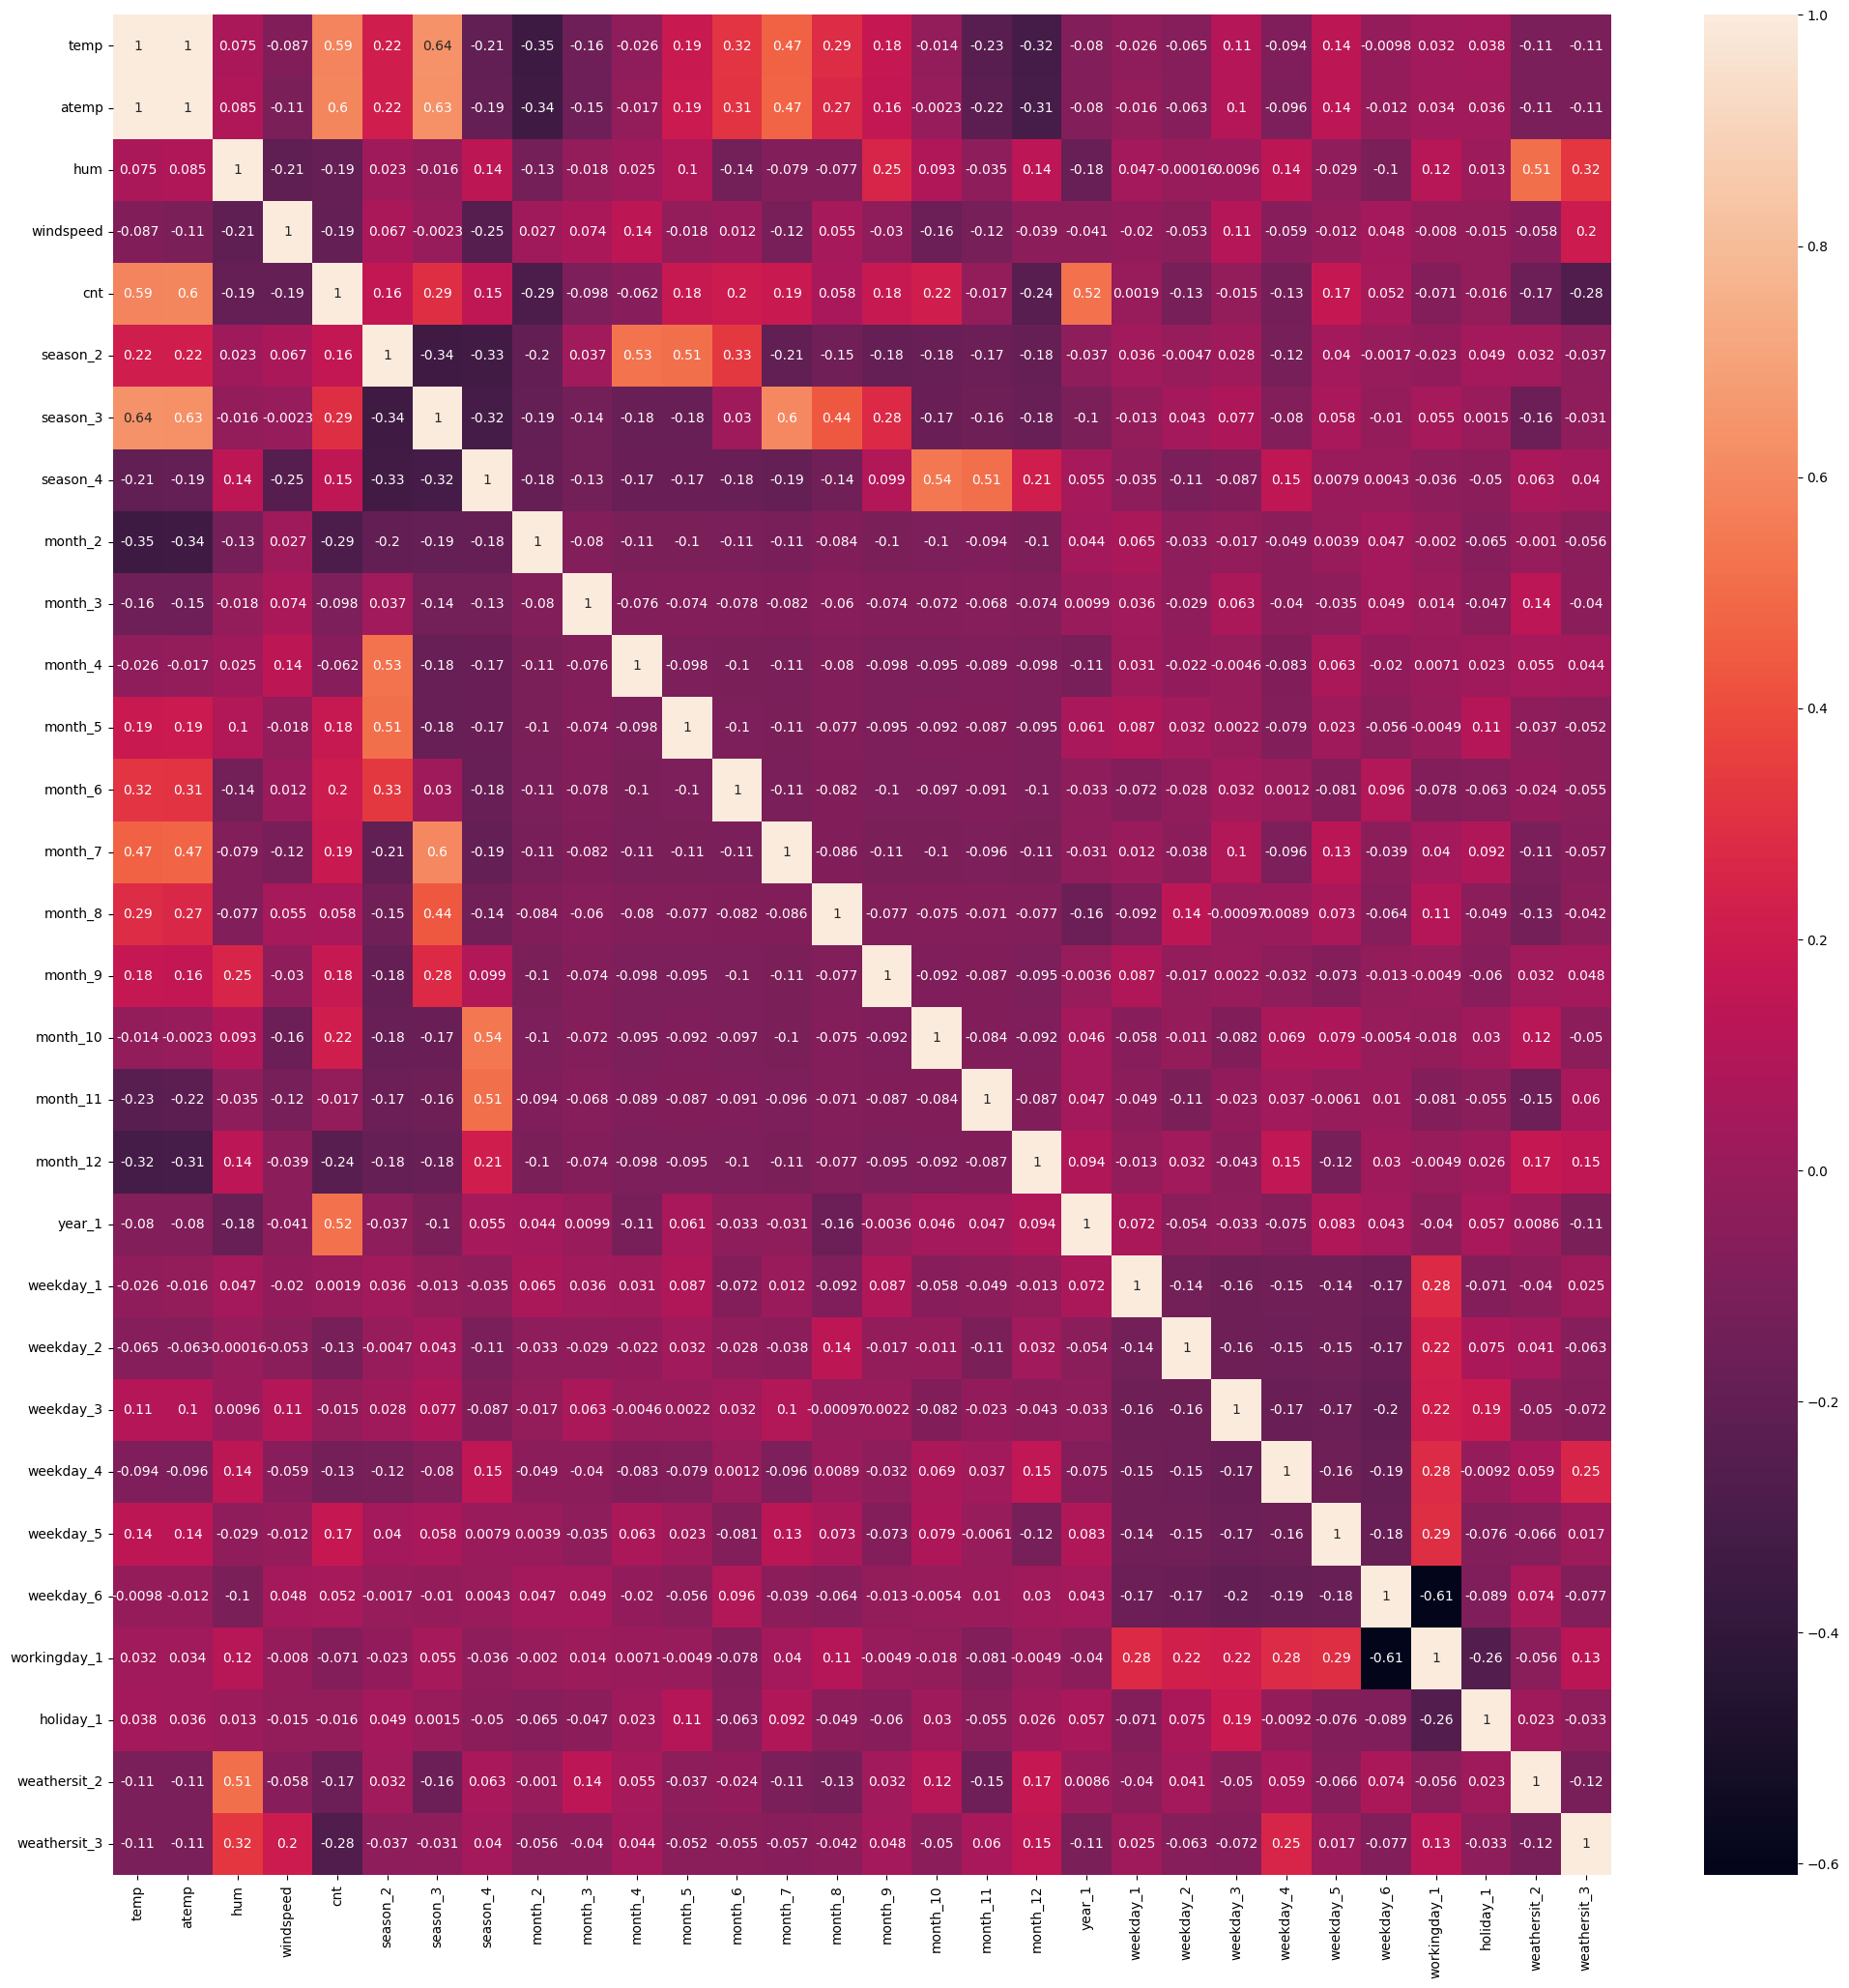

In [ ]:
plt.figure(figsize=(25,25))
sns.heatmap(df_test.corr(),annot=True)

In [ ]:
df_test.drop('atemp',inplace=True,axis=1)

In [ ]:
df_test.drop('temp',inplace=True,axis=1)

In [ ]:
df_test.drop('workingday_1',inplace=True,axis=1)

In [ ]:
df_test.drop('season_3',inplace=True,axis=1)

In [ ]:
df_test.drop('weekday_4',inplace=True,axis=1)

In [ ]:
df_test.drop('weekday_3',inplace=True,axis=1)

In [ ]:
df_test.drop('weekday_5',inplace=True,axis=1)

In [ ]:
df_test.drop('weekday_6',inplace=True,axis=1)

In [ ]:
df_test.drop('hum',inplace=True,axis=1)

In [ ]:
df_test.drop('season_2',inplace=True,axis=1)

In [ ]:
y_test=df_test.pop('cnt')
x_test=df_test

In [ ]:
x_test_sm = sm.add_constant ( x_test)

In [ ]:
y_test_pred = model.predict(x_test_sm)

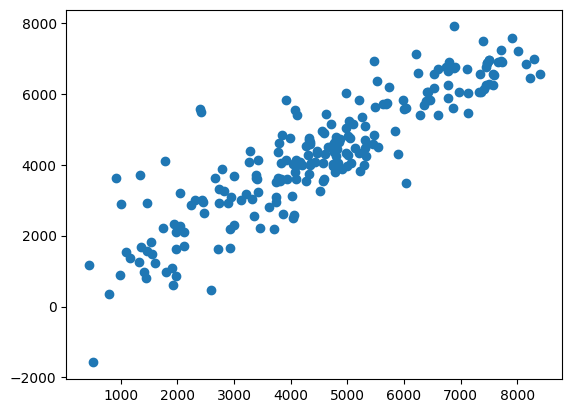

In [ ]:
plt.scatter(y_test, y_test_pred)

In [ ]:
np.sqrt(mean_squared_error(y_test, y_test_pred))

np.float64(897.5981938455006)

In [ ]:
r2_score(y_test, y_test_pred)

0.7754726642317442